# Portfolio construction under estimation error: does optimisation beat 1/N in a multi-asset universe?

Eight allocation rules are compared out of sample on eleven futures-like assets (US Treasuries, equities, currencies), 2003-2025. The rules range from equal weights, through risk-based rules, to mean-variance.

Every rule is re-estimated each month on the previous two years of daily data. It trades the next day at assumed costs and is scaled to the same 10% ex-ante volatility.

**Answer in brief.**

- **No rule is shown to beat 1/N.** In the main setting, the three rules that use the correlation structure or expected returns have higher Sharpe ratios than 1/N (0.43-0.49 against 0.25):
  - maximum diversification;
  - maximum Sharpe with sample means;
  - maximum Sharpe with Bayes-Stein means.

  The difference is not significant once the seven comparisons are accounted for (SPA p = 0.06; no Romano-Wolf rejection). Across all 96 configurations tried, the SPA p-value is 0.15.
- **Maximum diversification is the only rule ahead of 1/N in every setting** (Sharpe 0.35-0.44 against 0.22-0.32). Still, its edge over 1/N comes from few days: removing the 20 best days of the difference cuts its Sharpe ratio from 0.43 to 0.16.
- **Minimum variance is the worst rule.** It puts 95-96% of its risk in Treasuries and needs the 10x leverage cap 37% of the time. It lost 45% in the 2022 inflation shock, when bonds and equities fell together.
- **Costs do not decide the ranking at the assumed levels** (1-8.5 bp a year). Estimation error and the stock-bond correlation regime do.

Methods and derivations: [learning note](../../docs/learning/portfolio/portfolio_construction.md). Engines:

- `backtest_engine.covariance`: sample, EWMA and Ledoit-Wolf covariance;
- `backtest_engine.allocation`: the rules and the Euler risk decomposition;
- `backtest_engine.rebalance`: walk-forward rebalancing with drift, lag, costs and a volatility target;
- `backtest_engine.validation`: SPA and Romano-Wolf tests.

## 1. Research question

For a multi-asset investor who can use leverage (futures), does estimating the covariance matrix, and possibly expected returns, improve out-of-sample risk-adjusted returns after costs relative to the naive 1/N allocation?

Specifically:

1. Which rule has the highest Sharpe ratio net of costs, at equal ex-ante risk?
2. Is any advantage over 1/N statistically significant once every rule and setting tried is accounted for?
3. Does shrinkage (Ledoit-Wolf covariance, Bayes-Stein means) help the rules that invert the covariance matrix?
4. Where does each rule put its risk, and how does that explain its crisis behaviour?

## 2. Economic rationale

Markowitz (1952) mean-variance optimisation is optimal only if the means and covariances are known. With estimated inputs, the optimiser overweights assets whose mean is overestimated or whose risk is underestimated. Michaud (1989) calls it "error maximisation".

- **Means are the problem.** Chopra and Ziemba (1993) find that errors in means cost roughly ten times more than errors in variances. The t-statistic of a mean excess return is about SR x sqrt(T), with SR the annual Sharpe ratio and T in years: an asset with a Sharpe ratio of 0.3 needs 44 years of data to reach t = 2.
- **1/N is a demanding benchmark.** DeMiguel, Garlappi and Uppal (2009) find that none of 14 optimised models consistently beats 1/N out of sample. They estimate that sample mean-variance needs an estimation window of about 3,000 months to beat 1/N with 25 assets.
- **Risk-based rules avoid means.** Minimum variance, inverse volatility, equal risk contribution (ERC) and maximum diversification use only the covariance matrix, which is estimated far more precisely from daily data. Each is nevertheless the maximum-Sharpe portfolio under an implicit assumption about expected returns:
  - minimum variance, if all assets have the same expected return, so that the least volatile assets have the highest Sharpe ratios;
  - maximum diversification, if expected returns are proportional to volatility, so that all assets have the same Sharpe ratio (Choueifaty and Coignard, 2008);
  - ERC (risk parity) and inverse volatility, if in addition all correlations are equal (Maillard, Roncalli and Teiletche, 2010).
- **Shrinkage** trades bias for variance. It pulls the covariance towards a structured target (Ledoit and Wolf, 2004) and the means towards a common value (Jorion, 1986).

If risk-based rules or shrinkage work, it is because the implicit bet is approximately right and the variance reduction outweighs the bias. Whether they do is an empirical question, answered here out of sample.

## 3. Dataset

Eleven daily excess-return series built from official public data (Federal Reserve H.15 and H.10, Nasdaq, Nikkei, OECD; all via FRED). See `backtest_engine.universes` for the construction.

| Class | Assets | Construction |
|---|---|---|
| rates | UST 2Y, 10Y, 30Y | total return of a constant-maturity par bond from the H.15 yield, minus the T-bill |
| equity | Nasdaq Composite, Nikkei 225 in USD | price index return minus the T-bill (**no dividends**) |
| currency | EUR, GBP, JPY, CHF, CAD, AUD against USD | spot return plus the previous month's interest differential (OECD 3-month rates): a rolled forward |

Conventions:

- **Calendar:** US business days (the H.15 10-year yield calendar). Non-US series are carried forward for at most five days.
- **Cash:** 3-month T-bill (DTB3), accrued as rate x days / 360 from the previous day.
- **Annualisation:** 252 periods a year (the sample has 250 US business days a year on average).

These are research proxies for futures and forward positions, **not the returns of tradable contracts**. The equity series omit dividends (about 1-2% a year), which understates equity returns and favours equity-light rules.

The first date is 31 August 1999: the Swiss money-market rate starts in July 1999, and the previous month's rate is needed.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "backtest_engine").is_dir())
try:
    import backtest_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "backtest_engine"))
    import backtest_engine
from backtest_engine import allocation as al, covariance as cv, rebalance as rb, universes as un, validation as va
from backtest_engine.figstyle import (MUTED, NEGATIVE, NOTEBOOK, SERIES, figure_headline, headline, label_bar_segments,
                                      label_ends, notebook_style, ordinal_colors, percent_axis)

DATA_MODE = os.environ.get("BACKTEST_ENGINE_DATA_MODE", "official")   # "official" or "synthetic" (offline)

# Design fixed before any backtest was run (section 4): the main configuration and the robustness grid.
LOOKBACK, FREQUENCY, LAG = 504, "ME", 1        # two years of daily returns, month-end decisions, trade next day
TARGET_VOL, MAX_LEVERAGE = 0.10, 10.0          # ex-ante volatility target and gross-leverage cap
LOOKBACKS, FREQUENCIES, TARGETS = (252, 504, 1008), ("ME", "QE"), (0.10, None)
COST_BP = un.ASSUMED_COST_BP                 # one-way bp per unit of notional traded (assumptions; shown in section 3)
CRISES = {"Global financial crisis": ("2008-09-01", "2009-03-09"), "Euro-area debt crisis": ("2011-07-01", "2011-10-03"),
          "Taper tantrum": ("2013-05-01", "2013-06-24"), "COVID-19 crash": ("2020-02-19", "2020-03-23"),
          "2022 inflation shock": ("2022-01-03", "2022-10-14")}
PERIODS_PER_YEAR = 252.0
N_BOOT, SEED, ALPHA = 5000, 20260927, 0.05     # bootstrap replicate b uses the C++ stream (SEED, b)
OUTPUT_DIR = ROOT / "outputs" / "portfolio_construction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
notebook_style()
print(f"backtest_engine {backtest_engine.__version__} | data mode: {DATA_MODE}")

backtest_engine 0.1.0 | data mode: official


In [2]:
t0 = time.perf_counter()
returns = un.load_multi_asset_excess_returns() if DATA_MODE == "official" else un.synthetic_multi_asset()
ASSETS = list(returns.columns)
CLASSES = pd.Series(un.ASSET_CLASS)[ASSETS]
COSTS = pd.Series(COST_BP)[ASSETS] / 1e4
ann = np.sqrt(PERIODS_PER_YEAR)
print(f"{len(returns):,} daily excess returns, {returns.index[0]:%Y-%m-%d} to {returns.index[-1]:%Y-%m-%d} "
      f"({time.perf_counter() - t0:.1f} s)\nSource: {returns.attrs['source']}")
pd.DataFrame({"class": CLASSES, "mean (% a.)": returns.mean() * PERIODS_PER_YEAR * 100,
              "vol (% a.)": returns.std() * ann * 100, "Sharpe": returns.mean() / returns.std() * ann,
              "skew": returns.skew(), "excess kurtosis": returns.kurt(), "worst day (%)": returns.min() * 100,
              "assumed cost (bp)": COSTS * 1e4})

6,563 daily excess returns, 1999-08-31 to 2025-12-31 (0.2 s)
Source: Federal Reserve H.15 (Treasury yields, T-bill) and H.10 (exchange rates), Nasdaq Composite, Nikkei 225, OECD 3-month interbank rates; all via FRED


,class,mean (% a.),vol (% a.),Sharpe,skew,excess kurtosis,worst day (%),assumed cost (bp)
UST 2Y,rates,0.53,1.67,0.31,0.40,8.46,-0.74,0.50
UST 10Y,rates,2.09,7.76,0.27,0.06,2.60,-2.75,1.00
UST 30Y,rates,3.41,15.26,0.22,0.10,3.77,-7.20,1.50
Nasdaq,equity,9.36,25.08,0.37,0.04,6.12,-12.32,2.00
Nikkei (USD),equity,3.34,23.08,0.14,-0.12,4.91,-10.59,2.00
EUR,currency,0.22,9.23,0.02,0.15,2.58,-2.96,1.00
GBP,currency,0.30,9.31,0.03,-0.48,8.89,-7.84,1.00
JPY,currency,-2.94,9.99,-0.29,0.43,4.32,-3.29,1.00
CHF,currency,1.18,10.24,0.12,1.45,39.92,-8.51,1.00
CAD,currency,0.54,8.43,0.06,0.14,5.92,-3.74,1.00


The eleven assets span a **15:1 range of volatilities**, from 1.7% (2-year Treasury) to 25% (Nasdaq). Sharpe ratios are low everywhere: between -0.29 (the yen, a funding currency with a negative carry) and 0.37 (Nasdaq).

The currency block is a structural **short position in the US dollar**: 6 of 11 assets are long a foreign currency against the dollar. The Swiss franc's excess kurtosis of 40 comes from the removal of the EUR/CHF floor on 15 January 2015 (+13.9% in a day).

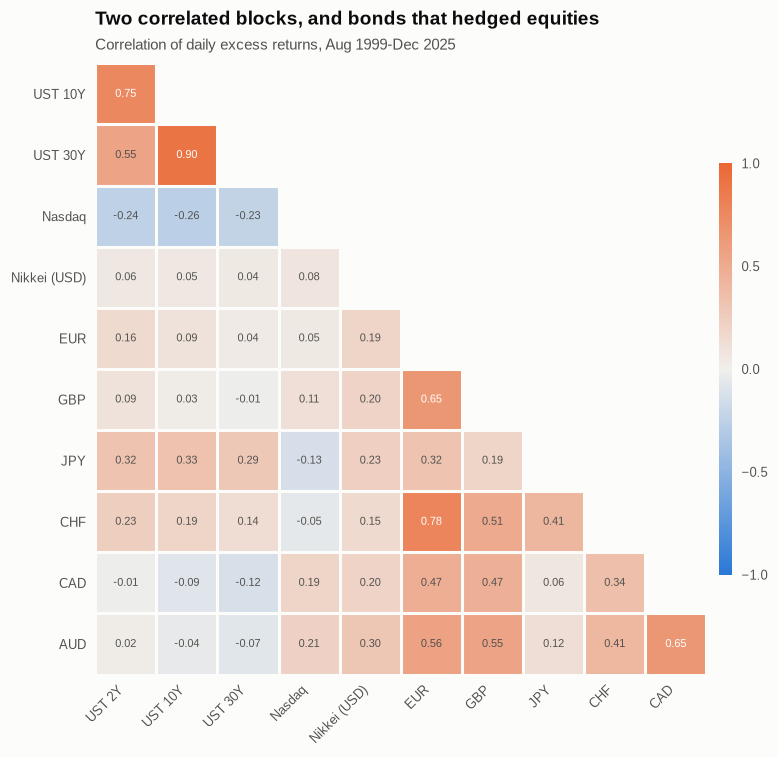

In [3]:
corr = returns.corr()
lower = corr.iloc[1:, :-1].where(np.tril(np.ones((len(ASSETS) - 1,) * 2, dtype=bool)))   # strict lower triangle
diverging = LinearSegmentedColormap.from_list("diverging", [SERIES[0], NOTEBOOK["neutral"], SERIES[1]])
fig, ax = plt.subplots(figsize=(7.0, 7.0))
im = ax.imshow(lower, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(ASSETS) - 1), ASSETS[:-1], rotation=45, ha="right")
ax.set_yticks(range(len(ASSETS) - 1), ASSETS[1:])
ax.set_xticks(np.arange(-0.5, len(ASSETS) - 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ASSETS) - 1), minor=True)
ax.grid(False)
ax.grid(which="minor", color=NOTEBOOK["surface"], linewidth=2)          # surface gaps between cells
ax.tick_params(which="both", length=0)
ax.spines[:].set_visible(False)
for i in range(len(ASSETS) - 1):
    for j in range(i + 1):
        v = lower.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > 0.6 else NOTEBOOK["ink2"])
bar = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02, aspect=30, ticks=[-1, -0.5, 0, 0.5, 1])
bar.outline.set_visible(False)
bar.ax.tick_params(length=0)
headline(ax, "Two correlated blocks, and bonds that hedged equities",
         f"Correlation of daily excess returns, {returns.index[0]:%b %Y}-{returns.index[-1]:%b %Y}")
fig.savefig(OUTPUT_DIR / "correlation.png", dpi=150)
plt.show()

## 4. Timing and information assumptions

| Step | When | Information used |
|---|---|---|
| decision | close of the last US business day of each month | the 504 daily returns up to and including that day |
| execution | close of the next business day (lag 1) | none; the targets are fixed at the decision |
| first return | the day after execution | |
| costs | charged on the execution day | assumed one-way cost x notional traded, per asset |
| drift | every day between trades | weights move with asset returns; no implicit daily rebalancing |

The volatility target scales each rule's weights by 10% / (ex-ante volatility of the weights). The ex-ante volatility uses the sample covariance of the same 504-day window, and the scaling is capped at a gross leverage of 10.

Comparing rules at equal ex-ante risk is what a levered investor (futures) does. It also makes differences in mean returns comparable across rules, because they are then roughly proportional to differences in Sharpe ratios.

The last, incomplete month is not traded. The unit tests (`tests/backtest_engine/test_rebalance.py`) check the timing. They also check that changing future returns never changes past decisions, and section 8 repeats that check on the real data.

**What was fixed in advance.** The main setting was chosen before any backtest was run:

- the eight rules;
- the 504-day window, monthly rebalancing and the one-day lag;
- the 10% volatility target;
- the cost assumptions;
- the crisis windows.

The leverage cap of 10 was set after looking at asset volatilities: a 2-year Treasury position needs about 6x to reach 10% volatility. The robustness grid (section 12) was added after the first run of the main setting. Every configuration run during the study is reported and included in the multiple-testing correction: 96 in all, with 8 rules and 12 settings.

## 5. Methodology

**Rules** (weights sum to one before volatility scaling; long only):

| Rule | Inputs | Weights |
|---|---|---|
| 1/N | none | $w_i = 1/N$ |
| Inverse vol | sample variances | $w_i \propto 1/\sigma_i$ |
| ERC (LW) | Ledoit-Wolf covariance | $w_i (\Sigma w)_i = \sigma_p / N$ for every $i$ (Spinu's convex formulation, Newton's method) |
| Min-var (sample, LW) | covariance | $\min_w w'\Sigma w$ subject to $w \ge 0$, $\mathbf{1}'w = 1$ |
| Max div (LW) | covariance | $\max_w w'\sigma / \sqrt{w'\Sigma w}$ (min-var on the correlation matrix, rescaled by $1/\sigma$) |
| Max Sharpe (sample) | sample means, sample covariance | $\max_w \mu'w / \sqrt{w'\Sigma w}$, $w \ge 0$ (exact, by non-negative least squares); cash if all $\mu_i \le 0$ |
| Max Sharpe (Bayes-Stein, LW) | shrunk means, LW covariance | as above with Jorion's (1986) means |

The **maximum-Sharpe** (tangency) portfolio is the mean-variance choice of an investor who can lever: whatever the risk aversion, they hold this portfolio scaled up or down. A mean-variance rule with an arbitrary risk-aversion parameter would therefore mix two effects, portfolio choice and leverage.

**Covariance estimators.** The sample covariance, and Ledoit-Wolf (2004) shrinkage towards the constant-correlation matrix. The shrinkage keeps the sample variances, replaces every correlation by the average one, and uses the intensity $\delta$ that minimises the estimated expected Frobenius loss.

**Costs (assumptions, not measurements)**, per unit of notional traded, one way:

- Treasuries 0.5 / 1 / 1.5 bp (2Y / 10Y / 30Y);
- equity indices 2 bp;
- currencies 1 bp.

These are of the order of half the bid-ask spread of the most liquid futures and forwards plus a small impact. Section 10 reports the cost multiple that would erase each rule's advantage.

**Statistics:**

- daily net returns, annualised with 252 periods;
- tests of the difference with 1/N, SPA (Hansen, 2005) and Romano-Wolf (2005), on the stationary bootstrap (5,000 replicates, seed 20260927);
- Euler decomposition of ex-ante volatility, $RC_i = w_i (\Sigma w)_i / \sigma_p$;
- Euler decomposition of realised expected shortfall, from the asset P&Ls on the worst 2.5% of days.

## 6. Exploratory evidence

Two features of the data matter for the rules.

1. **The stock-bond correlation changed sign.** It was negative for two decades, which made levered bonds the ideal hedge for equity risk. In 2021-2022 it turned positive. Minimum variance and risk parity depend on the negative correlation, and there was no hedge in 2022.
2. **Volatilities move by a factor of 5-7.** The 2-year Treasury's volatility fell from over 3% in 2009 to below 0.5% in 2013 and 2021. A rule that targets volatility then needs very large leverage on it.

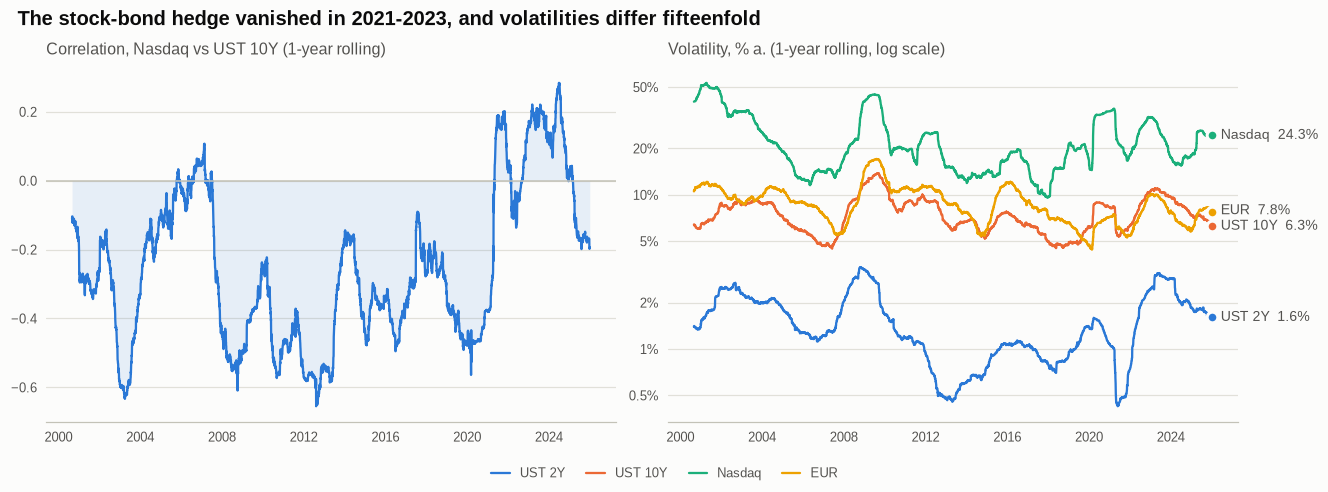

Stock-bond correlation by period: {'2000-2020': np.float64(-0.34), '2021-2025': np.float64(0.06)}


In [4]:
window = 252
stock_bond = returns["Nasdaq"].rolling(window).corr(returns["UST 10Y"]).dropna()
vols = (returns[["UST 2Y", "UST 10Y", "Nasdaq", "EUR"]].rolling(window).std() * ann * 100).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].fill_between(stock_bond.index, stock_bond, 0.0, color=SERIES[0], alpha=0.10, linewidth=0)
axes[0].plot(stock_bond.index, stock_bond, color=SERIES[0])
axes[0].axhline(0.0, color=NOTEBOOK["axis"], lw=1.0)
axes[0].set_title("Correlation, Nasdaq vs UST 10Y (1-year rolling)")
colors = dict(zip(vols.columns, SERIES))
for col in vols:
    axes[1].plot(vols.index, vols[col], color=colors[col], label=col)
axes[1].set_yscale("log")
axes[1].set_yticks([0.5, 1, 2, 5, 10, 20, 50], ["0.5%", "1%", "2%", "5%", "10%", "20%", "50%"])
axes[1].minorticks_off()
axes[1].set_title("Volatility, % a. (1-year rolling, log scale)")
label_ends(axes[1], {c: vols[c] for c in vols}, colors, fmt=lambda v: f"{v:.1f}%")
figure_headline(fig, "The stock-bond hedge vanished in 2021-2023, and volatilities differ fifteenfold")
fig.legend(*axes[1].get_legend_handles_labels(), loc="outside lower center", ncol=4)
fig.savefig(OUTPUT_DIR / "correlation_and_volatility.png", dpi=150)
plt.show()
print("Stock-bond correlation by period:",
      {p: round(returns.loc[a:b, "Nasdaq"].corr(returns.loc[a:b, "UST 10Y"]), 2)
       for p, (a, b) in {"2000-2020": ("2000", "2020"), "2021-2025": ("2021", "2025")}.items()})

Estimation error in the covariance is modest with daily data. The optimal Ledoit-Wolf intensity averages 0.09 with a one-year window, 0.05 with two years and 0.03 with four years. The sample covariance is already close to the best estimate, so shrinkage should change little for the covariance-only rules (checked in section 9).

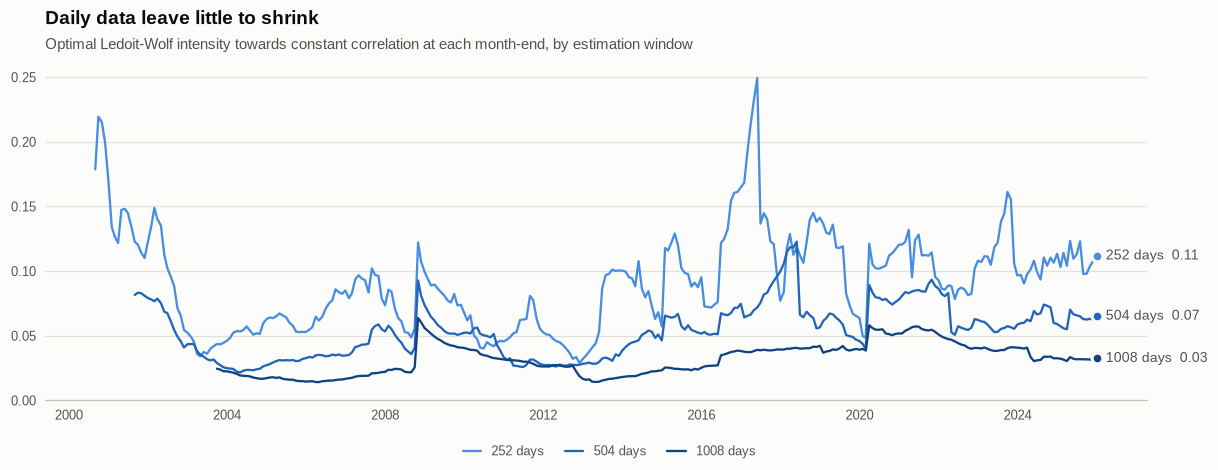

,mean,min,50%,max
252 days,0.09,0.03,0.09,0.25
504 days,0.05,0.02,0.05,0.12
1008 days,0.03,0.01,0.03,0.06


In [5]:
month_ends = rb.rebalance_dates(returns.index, "ME")
r = returns.to_numpy()
intensity = {}
for lb in LOOKBACKS:
    pos = [returns.index.get_loc(d) for d in month_ends if returns.index.get_loc(d) + 1 >= lb]
    intensity[f"{lb} days"] = pd.Series([cv.ledoit_wolf(r[p - lb + 1:p + 1])[1] for p in pos], index=returns.index[pos])
colors = dict(zip(intensity, ordinal_colors(len(LOOKBACKS) + 1)[1:]))
fig, ax = plt.subplots(figsize=(11.0, 4.2))
for name, s in intensity.items():
    ax.plot(s.index, s, color=colors[name], label=name)
ax.set_ylim(0, None)
label_ends(ax, intensity, colors, fmt=lambda v: f"{v:.2f}")
headline(ax, "Daily data leave little to shrink",
         "Optimal Ledoit-Wolf intensity towards constant correlation at each month-end, by estimation window")
fig.legend(loc="outside lower center", ncol=3)
fig.savefig(OUTPUT_DIR / "shrinkage_intensity.png", dpi=150)
plt.show()
pd.DataFrame({name: s.describe()[["mean", "min", "50%", "max"]] for name, s in intensity.items()}).T

## 7. Model: what the rules hold

Each rule is run in 12 settings: 3 windows (252, 504, 1008 days), 2 rebalancing frequencies (monthly, quarterly), and with or without the volatility target. All settings are evaluated on the same days, from the first date on which every configuration is invested.

In [6]:
def lw(window):
    return cv.ledoit_wolf(window, "constant_correlation")[0]


def sample(window):
    return cv.sample_covariance(window)


def max_sharpe_bayes_stein(window):
    cov = lw(window)
    return al.maximum_sharpe(al.bayes_stein_means(window, cov)[0], cov)


RULES = {
    "1/N": lambda w, current: al.equal_weight(w.shape[1]),
    "Inverse vol": lambda w, current: al.inverse_volatility(sample(w)),
    "ERC (LW)": lambda w, current: al.risk_budget(lw(w)),
    "Min-var (sample)": lambda w, current: al.minimum_variance(sample(w)),
    "Min-var (LW)": lambda w, current: al.minimum_variance(lw(w)),
    "Max div (LW)": lambda w, current: al.maximum_diversification(lw(w)),
    "Max Sharpe (sample)": lambda w, current: al.maximum_sharpe(w.mean(axis=0), sample(w)),
    "Max Sharpe (Bayes-Stein, LW)": lambda w, current: max_sharpe_bayes_stein(w),
}
HIGHLIGHT = {"ERC (LW)": SERIES[0], "Min-var (LW)": SERIES[1], "Max div (LW)": SERIES[2],
             "Max Sharpe (sample)": SERIES[3]}          # 1/N is drawn in grey as the reference


def run(rule, lookback=LOOKBACK, frequency=FREQUENCY, target_vol=TARGET_VOL, cost_multiplier=1.0):
    return rb.walk_forward_allocation(returns, RULES[rule], lookback=lookback, frequency=frequency, lag=LAG,
                                      cost=COSTS.to_numpy() * cost_multiplier, target_vol=target_vol,
                                      max_leverage=MAX_LEVERAGE, periods_per_year=PERIODS_PER_YEAR)


t0 = time.perf_counter()
SETTINGS = [(lb, fq, tv) for lb in LOOKBACKS for fq in FREQUENCIES for tv in TARGETS]
grid = {s: {rule: run(rule, *s) for rule in RULES} for s in SETTINGS}
main = grid[(LOOKBACK, FREQUENCY, TARGET_VOL)]
N_CONFIGURATIONS = len(SETTINGS) * len(RULES)
# Common evaluation period: from the day after the last configuration starts trading (the longest window needs
# four years of data), so every configuration is compared on the same days.
first_trade = max(out["daily"].index[out["daily"]["turnover"] > 0][0] for runs in grid.values() for out in runs.values())
EVAL_START = returns.index[returns.index.get_loc(first_trade) + 1]
print(f"{N_CONFIGURATIONS} configurations ({len(RULES)} rules x {len(SETTINGS)} settings) in "
      f"{time.perf_counter() - t0:.0f} s; common evaluation period {EVAL_START:%Y-%m-%d} to {returns.index[-1]:%Y-%m-%d}")

96 configurations (8 rules x 12 settings) in 46 s; common evaluation period 2003-10-02 to 2025-12-31


The exposure charts show the notional held, by asset class, at 10% ex-ante volatility. The weights differ far more than the Sharpe ratios in section 9 will:

- **Minimum variance** is almost only 2-year Treasuries, held at the 10x cap from 2012 to 2021.
- **Maximum Sharpe (sample)** jumps between concentrated portfolios. It holds nothing at all from mid-2022 to 2024, when every trailing two-year mean was negative: it is partly a trend filter.
- **ERC and maximum diversification** move smoothly with volatilities.

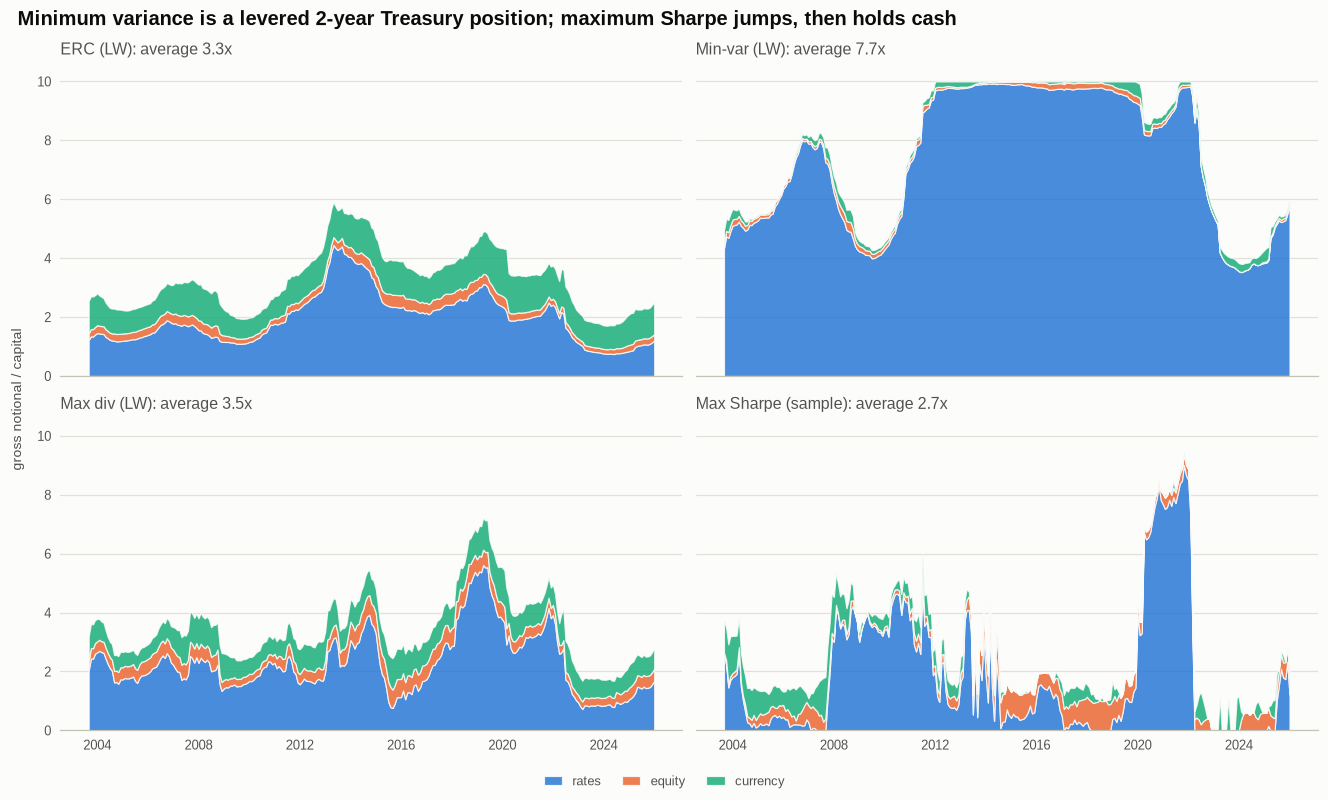

In [7]:
class_colors = {"rates": SERIES[0], "equity": SERIES[1], "currency": SERIES[2]}
fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.2), sharex=True, sharey=True)
for ax, rule in zip(axes.flat, HIGHLIGHT):
    exposure = main[rule]["targets"].abs().T.groupby(CLASSES).sum().T.loc[EVAL_START - pd.Timedelta(days=40):]
    ax.stackplot(exposure.index, *[exposure[c] for c in class_colors], colors=list(class_colors.values()),
                 labels=list(class_colors), alpha=0.85, edgecolor=NOTEBOOK["surface"], linewidth=0.8)
    ax.set_title(f"{rule}: average {exposure.sum(axis=1).mean():.1f}x")
fig.supylabel("gross notional / capital", fontsize=9, color=NOTEBOOK["ink2"])
figure_headline(fig, "Minimum variance is a levered 2-year Treasury position; maximum Sharpe jumps, then holds cash")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside lower center", ncol=3)
fig.savefig(OUTPUT_DIR / "exposure_by_class.png", dpi=150)
plt.show()

The Euler decomposition shows where each rule's risk sits, with one common risk model (Ledoit-Wolf, 504 days) for every rule.

- **1/N is a currency portfolio in disguise.** With 6 currencies out of 11 assets, currencies carry 55% of its risk, rates only 13.5%.
- **ERC gives each asset 1/11 of the risk,** so each class's share equals its number of assets: rates 27%, equities 18%, currencies 55%.
- **Minimum variance puts 95-96% of its risk in rates.**
- **The rules that win in section 9 put the most risk in equities** (39-47%): maximum diversification and maximum Sharpe.

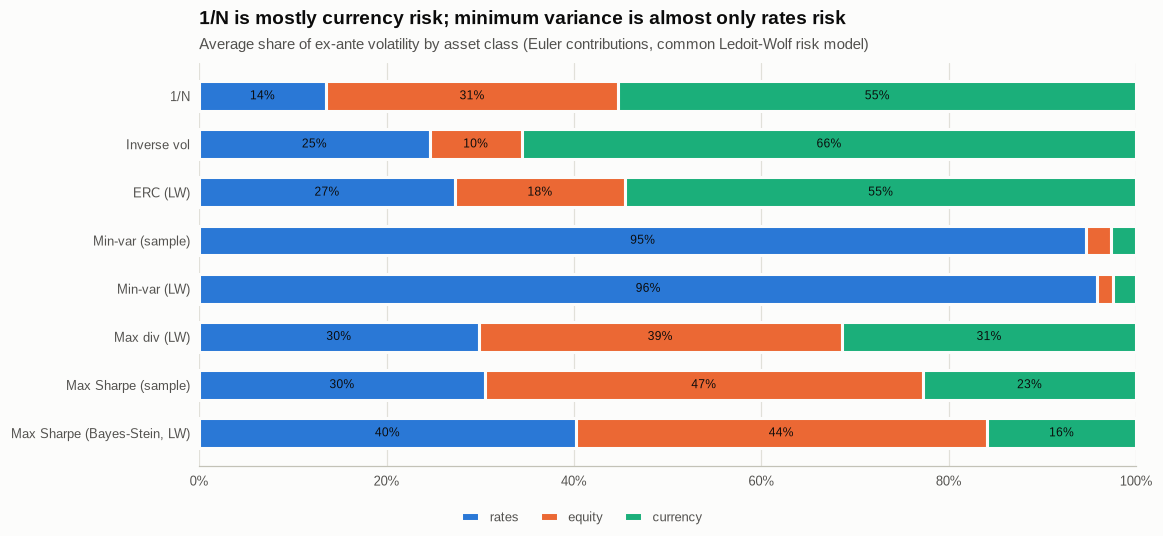

,rates,equity,currency
1/N,13.50,31.20,55.30
Inverse vol,24.60,9.80,65.60
ERC (LW),27.30,18.20,54.50
Min-var (sample),94.70,2.60,2.70
Min-var (LW),95.80,1.70,2.50
Max div (LW),29.80,38.80,31.40
Max Sharpe (sample),30.50,46.70,22.80
"Max Sharpe (Bayes-Stein, LW)",40.20,43.90,15.90


In [8]:
# Ex-ante Euler decomposition of volatility at each decision, with one common risk model (Ledoit-Wolf on the
# 504-day window) so that the rules are compared on the same yardstick.
decision_dates = main["1/N"]["targets"].loc[EVAL_START - pd.Timedelta(days=40):].index
risk_model = {d: lw(r[returns.index.get_loc(d) - LOOKBACK + 1:returns.index.get_loc(d) + 1]) for d in decision_dates}
shares = {}
for rule in RULES:
    rows = []
    for d in decision_dates:
        w = main[rule]["targets"].loc[d].to_numpy()
        if not w.any():
            continue
        rc = al.risk_contributions(w, risk_model[d])
        rows.append(pd.Series(rc / rc.sum(), index=ASSETS).groupby(CLASSES).sum())
    shares[rule] = pd.DataFrame(rows).mean() * 100
shares = pd.DataFrame(shares).T[list(class_colors)]
fig, ax = plt.subplots(figsize=(10.5, 4.8))
left = np.zeros(len(shares))
for c, color in class_colors.items():
    bars = ax.barh(shares.index, shares[c], left=left, color=color, label=c, height=0.62, linewidth=2)
    label_bar_segments(ax, bars, shares[c], lambda v: f"{v:.0f}%", min_value=9)
    left += shares[c].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 100)
percent_axis(ax, "x")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
headline(ax, "1/N is mostly currency risk; minimum variance is almost only rates risk",
         "Average share of ex-ante volatility by asset class (Euler contributions, common Ledoit-Wolf risk model)")
fig.legend(loc="outside lower center", ncol=3)
fig.savefig(OUTPUT_DIR / "risk_share_by_class.png", dpi=150)
plt.show()
shares.round(1)

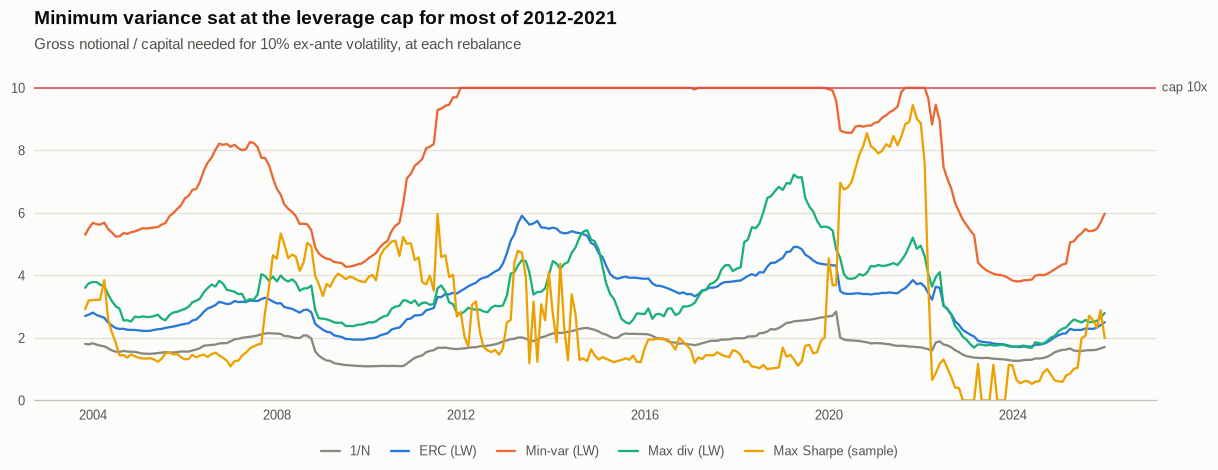

,% of rebalances at the cap
1/N,0.00
Inverse vol,0.00
ERC (LW),0.00
Min-var (sample),37.45
Min-var (LW),37.45
Max div (LW),0.00
Max Sharpe (sample),0.00
"Max Sharpe (Bayes-Stein, LW)",2.62


In [9]:
fig, ax = plt.subplots(figsize=(11.0, 4.2))
ax.plot(main["1/N"]["targets"].abs().sum(axis=1).loc[EVAL_START:], color=MUTED, label="1/N")
for rule, color in HIGHLIGHT.items():
    ax.plot(main[rule]["targets"].abs().sum(axis=1).loc[EVAL_START:], color=color, label=rule)
ax.axhline(MAX_LEVERAGE, color=NEGATIVE, lw=1.0)
ax.annotate(f"cap {MAX_LEVERAGE:.0f}x", (1.0, MAX_LEVERAGE), xycoords=("axes fraction", "data"), xytext=(4, 0),
            textcoords="offset points", va="center", fontsize=8.5, color=NOTEBOOK["ink2"], annotation_clip=False)
ax.set_ylim(0, MAX_LEVERAGE * 1.08)
headline(ax, "Minimum variance sat at the leverage cap for most of 2012-2021",
         "Gross notional / capital needed for 10% ex-ante volatility, at each rebalance")
fig.legend(loc="outside lower center", ncol=5)
fig.savefig(OUTPUT_DIR / "leverage.png", dpi=150)
plt.show()
at_cap = pd.Series({rule: (out["targets"].loc[EVAL_START:].abs().sum(axis=1) >= MAX_LEVERAGE - 1e-9).mean() * 100
                    for rule, out in main.items()}, name="% of rebalances at the cap")
at_cap.to_frame()

## 8. Validation

The allocation functions are checked in the unit tests:

- `tests/backtest_engine/test_allocation.py`:
  - closed forms and Karush-Kuhn-Tucker conditions for minimum variance and maximum Sharpe;
  - maximum Sharpe against 50,000 random portfolios;
  - equal risk contributions, including on a daily-scale covariance;
  - the special cases where ERC equals inverse volatility, and the ordering $\sigma_{\text{min-var}} \le \sigma_{\text{ERC}} \le \sigma_{1/N}$;
  - Euler sums, and ES contributions against the Gaussian closed form.
- `test_covariance.py`:
  - the identity-target Ledoit-Wolf matches scikit-learn;
  - the constant-correlation target matches a loop-by-loop transcription of the paper;
  - shrinkage reduces the Frobenius loss in simulation.
- `test_rebalance.py`: timing, drift, costs, the volatility target and no look-ahead.

Here the same properties are checked on the real data:

1. **ERC:** equal risk contributions at every rebalance.
2. **Volatility target:** the ex-ante volatility is exactly 10% at every rebalance.
3. **No look-ahead:** every return after 2 January 2015 is replaced by a scrambled series (reversed and multiplied by -3). The targets decided before that date and the P&L up to it must not change at all.
4. **Calibration of the volatility target:** realised volatility in each holding month relative to 10%.

In [10]:
checks = {}
# (a) Equal risk contributions hold at every rebalance under the covariance the rule used.
spread = []
for d in decision_dates:
    w = main["ERC (LW)"]["targets"].loc[d].to_numpy()
    rc = al.risk_contributions(w, risk_model[d])
    spread.append(np.ptp(rc) / rc.mean())
checks["ERC: max relative spread of risk contributions"] = max(spread)
# (b) Ex-ante volatility equals the target at every rebalance (up to the leverage cap).
w = main["1/N"]["targets"].loc[decision_dates]
checks["1/N: max |ex-ante vol - 10%| (pp)"] = max(
    abs(np.sqrt(w.loc[d].to_numpy() @ cv.sample_covariance(r[returns.index.get_loc(d) - LOOKBACK + 1:
        returns.index.get_loc(d) + 1]) @ w.loc[d].to_numpy() * PERIODS_PER_YEAR) - TARGET_VOL) * 100 for d in decision_dates)
# (c) No look-ahead on the real data: scramble every return after a cut-off; targets decided before it must not move.
cut = returns.index[returns.index.get_loc(pd.Timestamp("2015-01-02"))]
scrambled = returns.copy()
scrambled.loc[cut:] = -3.0 * scrambled.loc[cut:].to_numpy()[::-1]
for rule in ("Max Sharpe (sample)", "Min-var (LW)"):
    alt = rb.walk_forward_allocation(scrambled, RULES[rule], lookback=LOOKBACK, frequency=FREQUENCY, lag=LAG,
                                     cost=COSTS.to_numpy(), target_vol=TARGET_VOL, max_leverage=MAX_LEVERAGE)
    before = main[rule]["targets"].index < cut
    checks[f"{rule}: max target change before the cut-off"] = float(
        np.abs(main[rule]["targets"][before].to_numpy() - alt["targets"][before].to_numpy()).max())
    checks[f"{rule}: max daily P&L change before the cut-off"] = float(
        np.abs(main[rule]["daily"]["net"].loc[:cut].iloc[:-1] - alt["daily"]["net"].loc[:cut].iloc[:-1]).max())
# (d) Realised volatility in each holding month relative to the 10% target.
ratio = {}
for rule, out in main.items():
    net = out["daily"]["net"].loc[EVAL_START:]
    monthly_vol = net.groupby(net.index.to_period("M")).std() * ann
    ratio[rule] = (monthly_vol / TARGET_VOL).describe(percentiles=[0.1, 0.5, 0.9])[["10%", "50%", "90%"]]
display(pd.Series(checks, name="value").to_frame().style.format("{:.2e}"))
pd.DataFrame(ratio).T.rename(columns=lambda c: f"realised / target, {c}")

,value
ERC: max relative spread of risk contributions,4.30e-13
1/N: max |ex-ante vol - 10%| (pp),4.16e-15
Max Sharpe (sample): max target change before the cut-off,0.00e+00
Max Sharpe (sample): max daily P&L change before the cut-off,0.00e+00
Min-var (LW): max target change before the cut-off,0.00e+00
Min-var (LW): max daily P&L change before the cut-off,0.00e+00


,"realised / target, 10%","realised / target, 50%","realised / target, 90%"
1/N,0.63,0.85,1.39
Inverse vol,0.63,0.87,1.43
ERC (LW),0.64,0.89,1.41
Min-var (sample),0.49,0.79,1.46
Min-var (LW),0.49,0.80,1.48
Max div (LW),0.65,0.89,1.48
Max Sharpe (sample),0.55,0.86,1.54
"Max Sharpe (Bayes-Stein, LW)",0.51,0.84,1.59


The first three checks hold to machine precision.

The fourth shows the limits of a two-year volatility estimate:

- in the median month, realised volatility is 79-89% of the target, because the window still contains the last crisis;
- in one month in ten it is 40-60% above the target, because the window is slow to see a new one;
- over the full period, realised volatility is 10.3-10.9%.

The volatility target is right on average, not month by month.

## 9. Out-of-sample results

All results are out of sample in the walk-forward sense: every decision uses only past data. They are not out of sample with respect to the choice of rules, which were chosen knowing the literature.

In [11]:
def performance(out, start=EVAL_START, end=None):
    d = out["daily"].loc[start:end]
    net, gross = d["net"], d["gross"]
    wealth = (1.0 + net).cumprod()
    return {"return (% a.)": net.mean() * PERIODS_PER_YEAR * 100, "vol (% a.)": net.std() * ann * 100,
            "Sharpe net": net.mean() / net.std() * ann, "Sharpe gross": gross.mean() / gross.std() * ann,
            "max drawdown (%)": (wealth / wealth.cummax() - 1.0).min() * 100, "skew": net.skew(),
            "turnover (x a.)": d["turnover"].mean() * PERIODS_PER_YEAR, "costs (bp a.)": d["costs"].mean() * PERIODS_PER_YEAR * 1e4,
            "gross leverage": d["leverage"].mean()}


results = pd.DataFrame({rule: performance(out) for rule, out in main.items()}).T
results

,return (% a.),vol (% a.),Sharpe net,Sharpe gross,max drawdown (%),skew,turnover (x a.),costs (bp a.),gross leverage
1/N,2.63,10.59,0.25,0.25,-34.10,-0.49,0.68,0.83,1.78
Inverse vol,1.50,10.61,0.14,0.14,-40.66,-0.25,1.26,1.06,3.09
ERC (LW),2.37,10.79,0.22,0.22,-41.15,-0.36,1.48,1.28,3.27
Min-var (sample),1.43,10.32,0.14,0.14,-53.17,-0.01,2.74,1.76,7.76
Min-var (LW),1.30,10.30,0.13,0.13,-53.08,0.00,2.71,1.73,7.75
Max div (LW),4.64,10.86,0.43,0.43,-42.34,-0.42,3.38,2.74,3.49
Max Sharpe (sample),5.19,10.60,0.49,0.50,-39.73,-0.46,8.33,7.40,2.68
"Max Sharpe (Bayes-Stein, LW)",4.67,10.52,0.44,0.45,-46.41,-0.50,11.11,8.48,3.50


In the main setting:

- **The rules that use the correlation structure or means have the highest Sharpe ratios:**
  - maximum Sharpe (sample) 0.49;
  - maximum Sharpe (Bayes-Stein) 0.44;
  - maximum diversification 0.43.

  Against 1/N at 0.25, that is 2.0-2.6 percentage points a year more at about the same volatility.
- **The pure risk-reduction rules do worse than 1/N:** inverse volatility 0.14, ERC 0.22, minimum variance 0.13-0.14.
- **Shrinkage makes no material difference to minimum variance** (0.13 against 0.14), as section 6 predicted. Bayes-Stein means lower the Sharpe ratio of maximum Sharpe from 0.49 to 0.44 and raise its turnover.

The Sharpe ratios are low for every rule. Drawdowns of 34-53% at 10% volatility over 22 years show how much of the result depends on two episodes, 2008 and 2022.

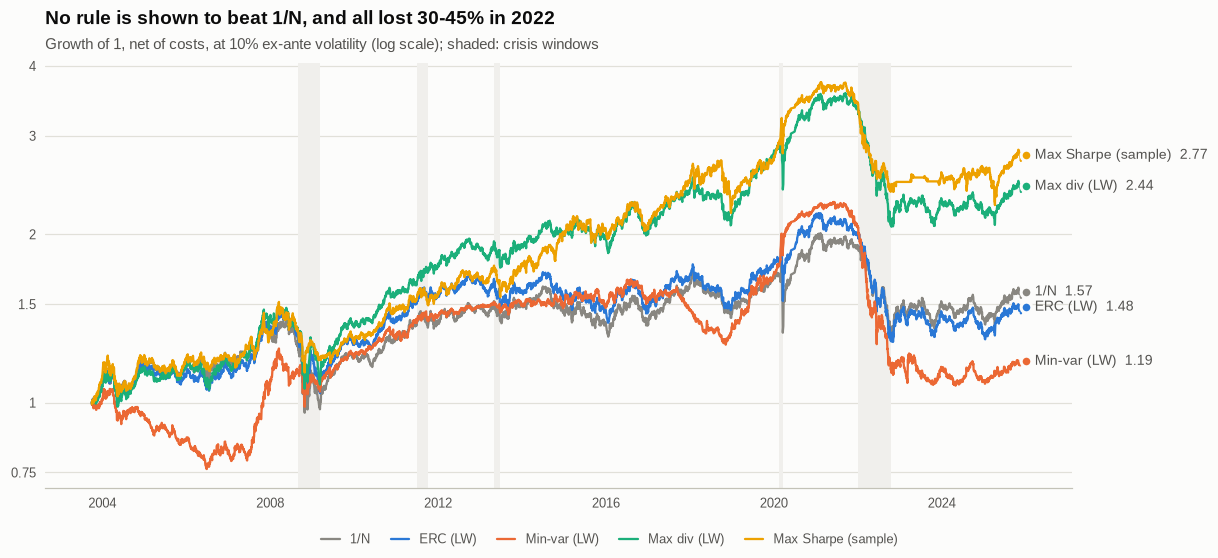

,Oct 2003-2008,2009-2019,2020-2025
1/N,0.25,0.45,-0.04
Inverse vol,0.45,0.23,-0.25
ERC (LW),0.38,0.42,-0.21
Min-var (sample),0.22,0.54,-0.42
Min-var (LW),0.23,0.52,-0.44
Max div (LW),0.47,0.78,-0.13
Max Sharpe (sample),0.46,0.74,0.09
"Max Sharpe (Bayes-Stein, LW)",0.57,0.72,-0.17


In [12]:
fig, ax = plt.subplots(figsize=(11.0, 5.0))
for name, (a, b) in CRISES.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=NOTEBOOK["neutral"], lw=0)
wealth = {rule: (1.0 + out["daily"]["net"].loc[EVAL_START:]).cumprod() for rule, out in main.items()}
colors = {"1/N": MUTED, **HIGHLIGHT}
for rule, color in colors.items():
    ax.plot(wealth[rule], color=color, label=rule, zorder=3)
ax.set_yscale("log")
ax.set_yticks([0.75, 1, 1.5, 2, 3, 4], ["0.75", "1", "1.5", "2", "3", "4"])
ax.minorticks_off()
label_ends(ax, {rule: wealth[rule] for rule in colors}, colors, fmt=lambda v: f"{v:.2f}")
headline(ax, "No rule is shown to beat 1/N, and all lost 30-45% in 2022",
         "Growth of 1, net of costs, at 10% ex-ante volatility (log scale); shaded: crisis windows")
fig.legend(loc="outside lower center", ncol=5)
fig.savefig(OUTPUT_DIR / "wealth.png", dpi=150)
plt.show()
PERIODS = {f"{EVAL_START:%b %Y}-2008": (EVAL_START, "2008-12-31"), "2009-2019": ("2009-01-01", "2019-12-31"),
           "2020-2025": ("2020-01-01", "2025-12-31")}
pd.DataFrame({p: {rule: performance(out, a, b)["Sharpe net"] for rule, out in main.items()}
              for p, (a, b) in PERIODS.items()})

**The ranking is not stable over time.**

- In 2009-2019, falling yields and a negative stock-bond correlation favoured every bond-heavy rule: minimum variance reached 0.52-0.54 and maximum diversification 0.78.
- In 2020-2025, every rule except maximum Sharpe (sample) has a negative Sharpe ratio. Minimum variance is the worst at -0.42 to -0.44.
- The only rule that stays positive, maximum Sharpe (sample), did so partly by holding cash after 2022 (section 7).

## 10. Costs

Costs are small at the assumed levels: 1-8.5 bp a year for turnover of 0.7-11 times capital a year.

The break-even multiple $k^*$ is the multiple of the assumed costs at which a rule's mean net return falls to that of 1/N. For the three rules ahead of 1/N:

- maximum diversification 107;
- maximum Sharpe (sample) 40;
- maximum Sharpe (Bayes-Stein) 28.

A negative $k^*$ means that the rule is behind 1/N before costs, so no cost level can help it.

Even at 20 times the assumed costs, the ranking of the top three is unchanged against 1/N:

- maximum diversification 0.38;
- maximum Sharpe (sample) 0.36;
- 1/N 0.23.

Costs would matter for a smaller investor trading less liquid instruments, or for daily rebalancing. They do not decide this comparison.

In [13]:
def net_sharpe(out, k):
    d = out["daily"].loc[EVAL_START:]
    net = d["gross"] - k * d["costs"]
    return net.mean() / net.std() * ann


eval_main = {rule: {"daily": out["daily"].loc[EVAL_START:]} for rule, out in main.items()}
cost_table = pd.DataFrame({
    "turnover (x a.)": results["turnover (x a.)"], "costs (bp a.)": results["costs (bp a.)"],
    "break-even k vs 1/N": {rule: rb.break_even_multiplier(v["daily"], eval_main["1/N"]["daily"]) for rule, v in eval_main.items()},
    "break-even k vs cash": {rule: rb.break_even_multiplier(v["daily"]) for rule, v in eval_main.items()},
    **{f"Sharpe at k={k}": {rule: net_sharpe(out, k) for rule, out in main.items()} for k in (0, 1, 5, 20)}})
cost_table

,turnover (x a.),costs (bp a.),break-even k vs 1/N,break-even k vs cash,Sharpe at k=0,Sharpe at k=1,Sharpe at k=5,Sharpe at k=20
1/N,0.68,0.83,NaN,316.79,0.25,0.25,0.24,0.23
Inverse vol,1.26,1.06,-496.51,142.86,0.14,0.14,0.14,0.12
ERC (LW),1.48,1.28,-55.63,186.03,0.22,0.22,0.21,0.20
Min-var (sample),2.74,1.76,-127.86,82.14,0.14,0.14,0.13,0.11
Min-var (LW),2.71,1.73,-146.70,76.56,0.13,0.13,0.12,0.09
Max div (LW),3.38,2.74,106.75,170.52,0.43,0.43,0.42,0.38
Max Sharpe (sample),8.33,7.40,40.10,71.18,0.50,0.49,0.46,0.36
"Max Sharpe (Bayes-Stein, LW)",11.11,8.48,27.71,56.05,0.45,0.44,0.41,0.29


## 11. Risk analysis

**Drawdowns and tail risk.** Every rule's worst drawdown starts from a 2021 peak and runs through the 2022 inflation shock. None had recovered by the end of 2025, when they were 22-48% below their peaks; minimum variance is the 48%. The 2008 drawdowns were smaller (21-32%).

Realised daily expected shortfall at 97.5% is similar across rules (1.9-2.1% of capital), as expected at equal ex-ante volatility. Its sources differ as much as the ex-ante risk shares in section 7:

- currencies drive 54% of the 1/N tail;
- rates drive 87-90% of the minimum-variance tail.

**Crisis windows** were fixed in advance from equity peaks and troughs and well-known bond sell-offs; they are not selected on strategy returns.

- 2008 and COVID-19 favoured the bond-heavy rules: minimum variance gained 8% in the COVID-19 crash while 1/N lost 19%.
- The 2022 inflation shock reversed this. Minimum variance lost 45% and every other rule lost 30-38%.
- The taper tantrum of 2013 was a small version of 2022, and every rule lost 4-12%.

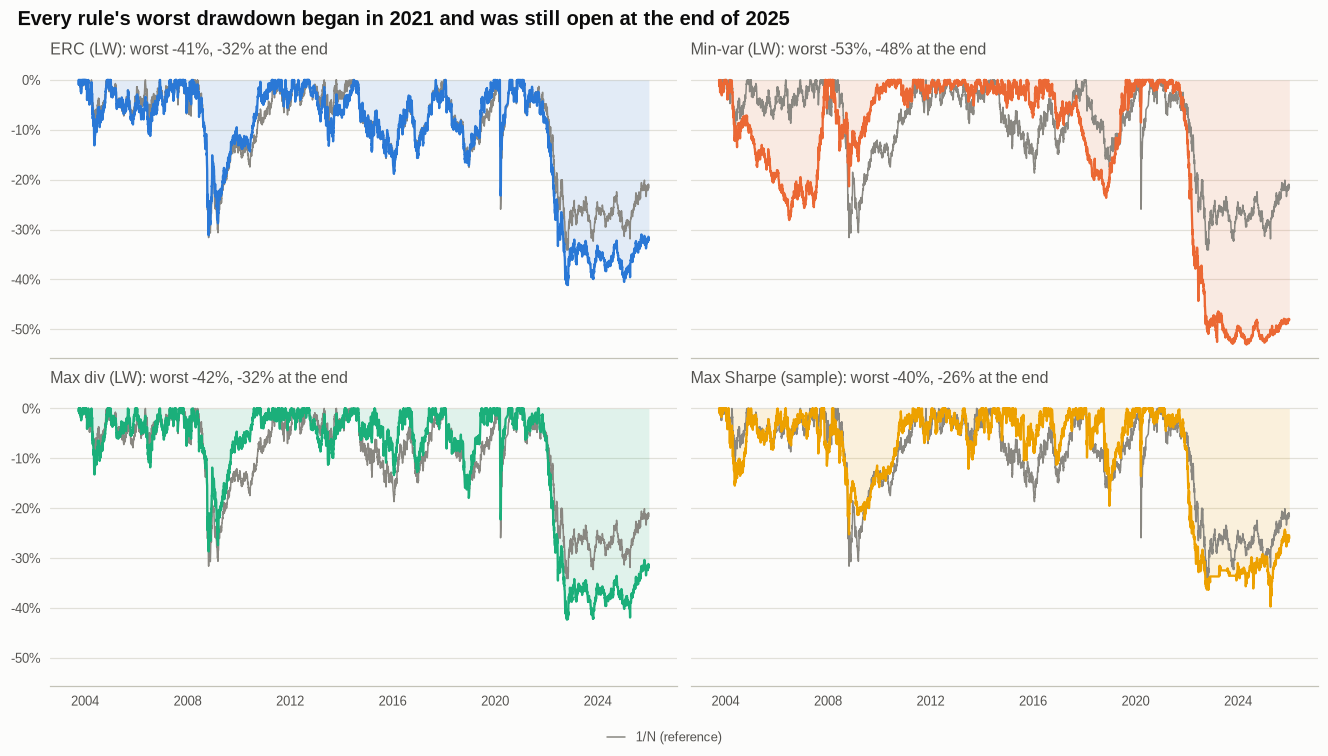

,ES 97.5% daily (%),rates share (%),equity share (%),currency share (%)
1/N,1.91,11.61,33.98,54.42
Inverse vol,1.89,24.75,10.03,65.22
ERC (LW),1.95,24.64,21.29,54.07
Min-var (sample),1.88,87.34,6.47,6.19
Min-var (LW),1.88,89.63,4.29,6.08
Max div (LW),1.95,27.33,40.50,32.16
Max Sharpe (sample),2.06,25.12,49.47,25.41
"Max Sharpe (Bayes-Stein, LW)",2.10,37.59,45.30,17.11


,Global financial crisis (%),Euro-area debt crisis (%),Taper tantrum (%),COVID-19 crash (%),2022 inflation shock (%)
1/N,-23.00,-1.64,-7.69,-19.13,-30.56
Inverse vol,-14.86,-0.30,-8.62,-9.52,-34.30
ERC (LW),-20.61,1.01,-10.17,-13.55,-35.84
Min-var (sample),-8.26,-0.17,-3.84,8.04,-44.87
Min-var (LW),-7.57,-0.04,-3.85,8.55,-44.68
Max div (LW),-20.00,4.02,-9.73,-14.66,-38.44
Max Sharpe (sample),-10.60,-2.64,-11.73,2.00,-30.70
"Max Sharpe (Bayes-Stein, LW)",-7.47,-4.77,-11.04,5.46,-35.34


In [14]:
from matplotlib.lines import Line2D

drawdown = {rule: (w / w.cummax() - 1.0) * 100 for rule, w in wealth.items()}
fig, axes = plt.subplots(2, 2, figsize=(12.0, 6.8), sharex=True, sharey=True)
for ax, (rule, color) in zip(axes.flat, HIGHLIGHT.items()):
    dd = drawdown[rule]
    ax.plot(drawdown["1/N"], color=MUTED, lw=1.0)
    ax.fill_between(dd.index, dd, 0.0, color=color, alpha=0.12, linewidth=0)
    ax.plot(dd, color=color)
    ax.set_title(f"{rule}: worst {dd.min():.0f}%, {dd.iloc[-1]:.0f}% at the end")
    percent_axis(ax)
figure_headline(fig, "Every rule's worst drawdown began in 2021 and was still open at the end of 2025")
fig.legend([Line2D([], [], color=MUTED, lw=1.0)], ["1/N (reference)"], loc="outside lower center")
fig.savefig(OUTPUT_DIR / "drawdowns.png", dpi=150)
plt.show()

# Realised expected shortfall and its exact Euler split: the day-t P&L of asset i is w_{i,t-1} r_{i,t}, so the
# asset P&Ls sum to the gross portfolio return and their means over the worst 2.5% of days sum to the ES.
es_rows = {}
for rule, out in main.items():
    held = out["weights"].shift(1).fillna(0.0).loc[EVAL_START:]
    pnl = held * returns.loc[EVAL_START:]
    components, es = al.expected_shortfall_contributions(np.ones(len(ASSETS)), pnl.to_numpy(), 0.975)
    by_class = pd.Series(components, index=ASSETS).groupby(CLASSES).sum()
    es_rows[rule] = {"ES 97.5% daily (%)": es * 100, **{f"{c} share (%)": by_class[c] / es * 100 for c in class_colors}}
display(pd.DataFrame(es_rows).T)
pd.DataFrame({name: {rule: ((1.0 + out["daily"]["net"].loc[a:b]).prod() - 1.0) * 100 for rule, out in main.items()}
              for name, (a, b) in CRISES.items()}).rename(columns=lambda c: f"{c} (%)")

## 12. Robustness

**Settings.** The chart shows the net Sharpe ratio of every configuration.

- **Maximum diversification is the only rule above 1/N in all 12 settings** (0.35-0.44, against 0.22-0.32 for 1/N).
- **Maximum Sharpe depends on the setting.** It ranges from 0.01 to 0.54 with sample means, and from -0.09 to 0.56 with Bayes-Stein means. It is well above 1/N only with the volatility target and monthly rebalancing on one- or two-year windows, where its leverage timing matters most.
- **The volatility target is not neutral.** It lowers the Sharpe ratio of 1/N (0.31 unlevered, 0.25 targeted, monthly, 504 days) and raises that of maximum Sharpe. Time-varying leverage is itself a bet, on volatility persistence.

**Multiple testing.** The tests take the dependence between configurations into account.

- For the seven rules against 1/N in the main setting, the best (maximum diversification, t = 2.19, naive p = 0.01) has an SPA p-value of 0.06 and a Romano-Wolf adjusted p-value of 0.06. No rejection at 5%.
- For all 84 rule-settings against 1/N in the same setting, the SPA p-value is 0.15. The 84 configurations amount to about 8 independent trials.

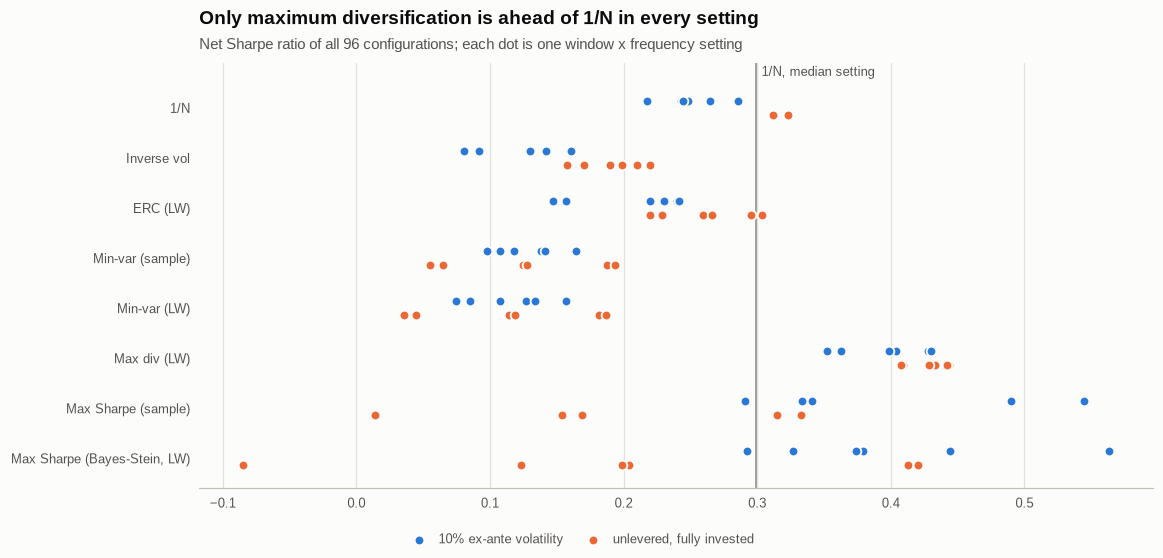

,1/N,Inverse vol,ERC (LW),Min-var (sample),Min-var (LW),Max div (LW),Max Sharpe (sample),"Max Sharpe (Bayes-Stein, LW)"
252d monthly 10% vol,0.22,0.08,0.15,0.11,0.09,0.36,0.54,0.56
252d monthly unlevered,0.31,0.16,0.22,0.06,0.04,0.41,0.17,0.12
252d quarterly 10% vol,0.24,0.09,0.16,0.10,0.07,0.35,0.34,0.38
252d quarterly unlevered,0.32,0.17,0.23,0.06,0.04,0.41,0.01,-0.09
504d monthly 10% vol,0.25,0.14,0.22,0.14,0.13,0.43,0.49,0.44
504d monthly unlevered,0.31,0.19,0.26,0.12,0.11,0.43,0.31,0.20
504d quarterly 10% vol,0.29,0.16,0.24,0.12,0.11,0.43,0.29,0.37
504d quarterly unlevered,0.32,0.20,0.27,0.13,0.12,0.43,0.15,0.20
1008d monthly 10% vol,0.24,0.13,0.23,0.16,0.16,0.40,0.34,0.33
1008d monthly unlevered,0.31,0.21,0.30,0.19,0.18,0.44,0.33,0.41


In [15]:
def label(s):
    lb, fq, tv = s
    return f"{lb}d {'monthly' if fq == 'ME' else 'quarterly'} {'10% vol' if tv else 'unlevered'}"


sharpe_grid = pd.DataFrame({label(s): {rule: performance(out)["Sharpe net"] for rule, out in runs.items()}
                            for s, runs in grid.items()})
fig, ax = plt.subplots(figsize=(10.5, 5.0))
ypos = np.arange(len(RULES))[::-1]
reference = sharpe_grid.loc["1/N"].median()
ax.axvline(reference, color=MUTED, lw=1.0)
ax.annotate("1/N, median setting", (reference, 1.0), xycoords=("data", "axes fraction"), xytext=(4, -2),
            textcoords="offset points", va="top", fontsize=8.5, color=NOTEBOOK["ink2"])
for k, (tv, color, name) in enumerate(((0.10, SERIES[0], "10% ex-ante volatility"),
                                       (None, SERIES[1], "unlevered, fully invested"))):
    cols = [label(s) for s in SETTINGS if s[2] == tv]
    for j, rule in enumerate(RULES):
        ax.scatter(sharpe_grid.loc[rule, cols], np.full(len(cols), ypos[j] + (0.14 if k == 0 else -0.14)), s=40,
                   color=color, edgecolors=NOTEBOOK["surface"], linewidths=1.2, label=name if j == 0 else None,
                   zorder=3)
ax.set_yticks(ypos, list(RULES))
ax.set_ylim(-0.6, len(RULES) - 0.1)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
headline(ax, "Only maximum diversification is ahead of 1/N in every setting",
         f"Net Sharpe ratio of all {N_CONFIGURATIONS} configurations; each dot is one window x frequency setting")
fig.legend(loc="outside lower center", ncol=2)
fig.savefig(OUTPUT_DIR / "robustness.png", dpi=150)
plt.show()
sharpe_grid.T

In [16]:
evaluation = pd.DataFrame({rule: out["daily"]["net"].loc[EVAL_START:] for rule, out in main.items()})
t0 = time.perf_counter()
test_main = va.SnoopingTest(evaluation.drop(columns="1/N"), benchmark=evaluation["1/N"], n_boot=N_BOOT, seed=SEED)
# Every configuration against 1/N in the same setting (same window, frequency and volatility treatment).
differences = pd.DataFrame({f"{rule} | {label(s)}": runs[rule]["daily"]["net"].loc[EVAL_START:] - runs["1/N"]["daily"]["net"].loc[EVAL_START:]
                            for s, runs in grid.items() for rule in RULES if rule != "1/N"})
test_grid = va.SnoopingTest(differences, n_boot=N_BOOT, seed=SEED)
print(f"bootstrap tests in {time.perf_counter() - t0:.0f} s")
summary = pd.DataFrame({"main setting, 7 rules vs 1/N": test_main.summary(ALPHA),
                        f"all settings, {differences.shape[1]} rule-settings vs 1/N": test_grid.summary(ALPHA)})
display(summary.map(lambda v: f"{v:.3f}" if isinstance(v, float) else v))
rw = test_main.romano_wolf(ALPHA)
rw["mean"] *= PERIODS_PER_YEAR * 100
display(rw.rename(columns={"mean": "mean difference (% a.)"}))
print(f"effective number of independent trials in the full grid: {test_grid.effective_trials():.1f} "
      f"of {differences.shape[1]}")

bootstrap tests in 1 s


,"main setting, 7 rules vs 1/N","all settings, 84 rule-settings vs 1/N"
strategies,7,84
periods,5541,5541
mean block,2.378,3.642
best,Max div (LW),Max div (LW) | 504d monthly 10% vol
best t,2.194,2.255
naive p,0.014,0.012
Reality Check p,0.195,0.187
SPA p (consistent),0.059,0.146
SPA p (lower),0.038,0.098
SPA p (upper),0.059,0.147


,mean difference (% a.),t,p_adjusted,p_single,reject
strategy,,,,,
Max div (LW),2.02,2.19,0.06,0.01,False
Max Sharpe (sample),2.57,1.36,0.24,0.09,False
"Max Sharpe (Bayes-Stein, LW)",2.04,1.03,0.35,0.15,False
ERC (LW),-0.25,-0.44,0.84,0.67,False
Min-var (sample),-1.20,-0.55,0.84,0.71,False
Min-var (LW),-1.32,-0.60,0.85,0.73,False
Inverse vol,-1.13,-1.50,0.93,0.93,False


effective number of independent trials in the full grid: 8.2 of 84


**Episode dependence.** The difference between maximum diversification and 1/N has a Sharpe ratio of 0.43 (2% a year). Removing its 5, 10 and 20 best days lowers that to 0.35, 0.28 and 0.16.

A robust structural edge would degrade more slowly. This one is a sum of many small daily differences plus a few large ones, concentrated in the crises where the two rules hold different assets.

In [17]:
best = test_main.naive()["best"]
edge = evaluation[best] - evaluation["1/N"]
print(f"{best} minus 1/N: how much of the difference comes from a few days")
episodes = va.episode_dependence(edge)
episodes["annual mean"] *= 100
episodes.rename(columns={"annual mean": "annual mean (%)"})

Max div (LW) minus 1/N: how much of the difference comes from a few days


annual mean (%)  Sharpe
periods removed which                                 
0               none                      2.02    0.43
5               best removed              1.61    0.35
                worst removed             2.46    0.54
10              best removed              1.27    0.28
                worst removed             2.76    0.61
20              best removed              0.71    0.16
                worst removed             3.27    0.73

## 13. Failure modes

1. **Correlation regime change (2022).**
   - Every rule that uses bonds to hedge equities assumes the negative stock-bond correlation of 2000-2020.
   - With inflation, it turned positive and bonds lost as much as equities.
   - Levered bond positions turned a bond bear market into the largest loss of the sample for minimum variance (additive P&L from rates of -52% of capital in 2022).
2. **Leverage on low-volatility assets.**
   - Equal-risk and volatility-targeting rules lever the least volatile assets most.
   - When volatility is low for years (2-year Treasuries 2012-2021), the leverage is largest just before volatility rises: volatility is mean-reverting and the estimate is backward-looking.
   - The 10x cap bound 37% of the time for minimum variance.
3. **Hidden concentration in 1/N.** Equal weights by asset are not equal risk by source. The 1/N portfolio is mostly a short-dollar bet: 55% of risk, and 15% of capital lost on currencies in 2022.
4. **Noisy means.**
   - Maximum Sharpe with sample means turns over 8 times a year.
   - It jumps between concentrated portfolios, and holds cash when trailing means are negative.
   - Its high Sharpe ratio in the main setting does not survive quarterly rebalancing or unlevered weights.
5. **Two-year windows are slow.** In the month a crisis starts, the ex-ante volatility does not yet contain it: in one month in ten, realised volatility is 40-60% above target.

In [18]:
# Gross P&L by asset class during the 2022 inflation shock (sum of daily w_{i,t-1} r_{i,t}, in % of capital).
a, b = CRISES["2022 inflation shock"]
attribution = {}
for rule, out in main.items():
    pnl = (out["weights"].shift(1).fillna(0.0) * returns).loc[a:b]
    attribution[rule] = pnl.sum().groupby(CLASSES).sum() * 100
attribution = pd.DataFrame(attribution).T[list(class_colors)]
attribution["sum"] = attribution.sum(axis=1)
attribution["compounded net return"] = [((1.0 + out["daily"]["net"].loc[a:b]).prod() - 1.0) * 100 for out in main.values()]
attribution.rename(columns=lambda c: f"{c} (%)")

,rates (%),equity (%),currency (%),sum (%),compounded net return (%)
1/N,-9.96,-11.02,-14.65,-35.64,-30.56
Inverse vol,-15.98,-4.95,-20.07,-41.00,-34.30
ERC (LW),-18.48,-6.73,-18.11,-43.33,-35.84
Min-var (sample),-52.38,-1.61,-3.51,-57.50,-44.87
Min-var (LW),-52.52,-1.29,-3.35,-57.16,-44.68
Max div (LW),-23.45,-10.65,-13.28,-47.38,-38.44
Max Sharpe (sample),-16.12,-15.30,-4.26,-35.69,-30.70
"Max Sharpe (Bayes-Stein, LW)",-29.65,-12.15,-0.59,-42.39,-35.34


## 14. Conclusion

In this universe, over 2003-2025, net of assumed costs and at equal ex-ante risk:

- **No allocation rule is shown to beat 1/N.** Maximum diversification is the most consistent candidate (ahead of 1/N in all 12 settings). Its advantage is not significant after accounting for the configurations tried (SPA p = 0.06 in the main setting, 0.15 over all 96), and it depends on a few days.
- **Minimum variance and risk parity underperformed 1/N.** Both concentrate risk in rates, and both were hit by the end of the negative stock-bond correlation in 2022.
- **Shrinkage mattered little** for the covariance with daily data, and Bayes-Stein means did not improve maximum Sharpe here.
- **Costs are not the constraint** for liquid futures at monthly frequency. Estimation error, the correlation regime and leverage are.

A defensible allocation for this universe would therefore start from a simple rule (1/N or ERC by asset class, rather than by asset) with explicit leverage limits. It would then be stress-tested for positive stock-bond correlation, rather than chosen by in-sample Sharpe ratio.

## 15. Limitations

- **Proxies, not contracts.** Treasury returns come from constant-maturity yields (no futures basis or delivery option). Equity returns are price indices without dividends. Currency returns use monthly-average interbank rates instead of forward points.
- **Costs are assumed,** not measured from quotes, and leverage is assumed to be free apart from the financing embedded in excess returns. Margin and funding constraints of a 10x position are ignored.
- **One universe of 11 assets,** a fifth of them highly correlated Treasuries. Results could differ with commodities, credit or more equity markets.
- **Short effective history for regime questions:** one inflation shock (2022) and two equity crises. The failure modes are documented, not statistically estimated.
- **Rules chosen with knowledge of the literature.** The walk-forward design removes look-ahead in the data, not in the researcher.

### References

- Choueifaty, Y. and Coignard, Y. (2008). Toward maximum diversification. *Journal of Portfolio Management*, 35(1), 40-51.
- Chopra, V. K. and Ziemba, W. T. (1993). The effect of errors in means, variances, and covariances on optimal portfolio choice. *Journal of Portfolio Management*, 19(2), 6-11.
- DeMiguel, V., Garlappi, L. and Uppal, R. (2009). Optimal versus naive diversification: how inefficient is the 1/N portfolio strategy? *Review of Financial Studies*, 22(5), 1915-1953.
- Hansen, P. R. (2005). A test for superior predictive ability. *Journal of Business and Economic Statistics*, 23(4), 365-380.
- Jorion, P. (1986). Bayes-Stein estimation for portfolio analysis. *Journal of Financial and Quantitative Analysis*, 21(3), 279-292.
- Ledoit, O. and Wolf, M. (2004). Honey, I shrunk the sample covariance matrix. *Journal of Portfolio Management*, 30(4), 110-119.
- Maillard, S., Roncalli, T. and Teiletche, J. (2010). The properties of equally weighted risk contribution portfolios. *Journal of Portfolio Management*, 36(4), 60-70.
- Markowitz, H. (1952). Portfolio selection. *Journal of Finance*, 7(1), 77-91.
- Michaud, R. O. (1989). The Markowitz optimization enigma: is 'optimized' optimal? *Financial Analysts Journal*, 45(1), 31-42.
- Romano, J. P. and Wolf, M. (2005). Stepwise multiple testing as formalized data snooping. *Econometrica*, 73(4), 1237-1282.
- Spinu, F. (2013). An algorithm for computing risk parity weights. SSRN working paper 2297383.
- Tasche, D. (2000). Risk contributions and performance measurement. Working paper, Technische Universität München.